In [15]:
import numpy as np, pandas as pd, torch, os
from dataclasses import dataclass
from torch.utils.data import TensorDataset, DataLoader
from sklearn.tree import DecisionTreeRegressor
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   

from ablation_utils.uncertainty import (
    UncertaintyData, ProbabilityEnsemble, ConstantEU, VarianceEU, KNNRadius,
)
from ablation_utils.data import undersample
import ablation_utils.neural_net as anet

os.makedirs("plots", exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [16]:
from ablation_utils.data import hetero_1d, california, bike
# data = hetero_1d(seed=0);    dataname = "HETERO_1D"
data = california(seed=0); dataname = "CALIFORNIA"
# data = bike(seed=0);       dataname = "BIKE"

X_train, y_train = data.X_train, data.y_train
X_calib, y_calib = data.X_calib, data.y_calib
X_test,  y_test  = data.X_test,  data.y_test
n_calib, group_test = data.n_calib, data.group_test
print(data.summary())

california: d = 8, n_train = 6434, n_calib = 2000, n_test = 8000
  eu    train     48   test   1611
  rest  train   6386   test   6389


In [17]:
from ablation_utils.uncertainty import ProbabilityEnsemble, ConstantEU, VarianceEU, KNNRadius
model = ProbabilityEnsemble(DecisionTreeRegressor(min_samples_leaf=5), k=25)
model.fit(X_train, y_train)

# s(x,y) = |f(x) - y| / scale(x); scale = 1 is MAE. Swap scale_fn for locally normalised scores.
scale_fn = lambda Xa: np.ones(len(Xa))

f_calib, f_test = model.predict(X_calib), model.predict(X_test)
s_calib, s_test = scale_fn(X_calib), scale_fn(X_test)
S_calib = np.abs(f_calib - y_calib) / s_calib
S_test  = np.abs(f_test  - y_test)  / s_test
print(f"R^2 calib {model.score(X_calib, y_calib):.3f} | test {model.score(X_test, y_test):.3f}")

R^2 calib 0.361 | test 0.351


In [18]:
uncertainty_methods = {
    "constant": ConstantEU(),
    "variance": VarianceEU(model),
    "knn":      KNNRadius(n_neighbors=25, standardize=True),
}
train_data, calib_data, test_data = (UncertaintyData(X=X_train), UncertaintyData(X=X_calib),
                                     UncertaintyData(X=X_test))
for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)

U_loo  = {k: m.transform_loo(calib_data)       for k, m in uncertainty_methods.items()}
U_test = {k: m.transform_normalized(test_data) for k, m in uncertainty_methods.items()}

EU      = (group_test == "eu")
METHODS = list(uncertainty_methods)
AWARE   = [m for m in METHODS if m != "constant"]

In [19]:
#   y ∈ C(x)  ⇔  S ≤ Σ / ((n+1)α − 1),   Size = 2·scale(x)·Σ / ((n+1)α − 1)
#   α*(x) = min{1, (1 + sqrt(2·scale(x)·Σ·(n+1) / (λ·u(x)))) / (n+1)}

def radius(Sigma, n, alpha, scale=1.0):
    denom = (n + 1) * np.asarray(alpha, float) - 1.0
    return np.where(denom > 0, scale * Sigma / np.clip(denom, 1e-12, None), np.inf)

def alpha_star(Sigma, n, lam, u, scale=1.0, max_alpha=1.0):
    a = (1.0 + np.sqrt(2.0 * scale * Sigma * (n + 1) / (lam * np.clip(u, 1e-12, None)))) / (n + 1)
    return np.minimum(a, max_alpha)

def reg_loss(Sigma, n, alpha, lam, u, scale=1.0):
    return 2 * radius(Sigma, n, alpha, scale) + lam * u * np.asarray(alpha, float)

n_loo     = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib        # LOO episode i
Sigma_te  = float(S_calib.sum())

In [20]:
# choosing a reasonable lambda
ALPHA_TARGET = 0.10
m = n_calib + 1
lam = 2.0 * Sigma_te * m / ((m * ALPHA_TARGET - 1.0) ** 2)
print(f"lam = {lam:.2f} -> alpha*(u=1) = {alpha_star(Sigma_te, n_calib, lam, 1.0):.3f}")

lam = 72.87 -> alpha*(u=1) = 0.100


In [21]:
closed = {n: {"alpha_loo":  alpha_star(Sigma_loo, n_loo,  lam, U_loo[n],  s_calib),
              "alpha_test": alpha_star(Sigma_te,  n_calib, lam, U_test[n], s_test)}
          for n in METHODS}


[constant] run 1/4
  lam 72.8721259469609 | run 1 | epoch 0/200 | loss 17.1881 | size 6.4724 | alpha 0.1470
  early stop at epoch 22

[constant] run 2/4
  lam 72.8721259469609 | run 2 | epoch 0/200 | loss 17.8550 | size 6.5342 | alpha 0.1554
  early stop at epoch 22

[constant] run 3/4
  lam 72.8721259469609 | run 3 | epoch 0/200 | loss 17.0969 | size 6.6300 | alpha 0.1436
  early stop at epoch 22

[constant] run 4/4
  lam 72.8721259469609 | run 4 | epoch 0/200 | loss 17.5024 | size 6.5522 | alpha 0.1503
  early stop at epoch 22

[variance] run 1/4
  lam 72.8721259469609 | run 1 | epoch 0/200 | loss 16.5706 | size 6.9429 | alpha 0.1695
  lam 72.8721259469609 | run 1 | epoch 25/200 | loss 12.9482 | size 6.4556 | alpha 0.1588
  lam 72.8721259469609 | run 1 | epoch 50/200 | loss 12.9488 | size 6.4581 | alpha 0.1608
  early stop at epoch 60

[variance] run 2/4
  lam 72.8721259469609 | run 2 | epoch 0/200 | loss 17.5946 | size 7.1937 | alpha 0.1807
  lam 72.8721259469609 | run 2 | epoch 25

c:\Users\User\Documents\learning-uncertainty-aware-policies\ablation_utils\neural_net.py:468: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


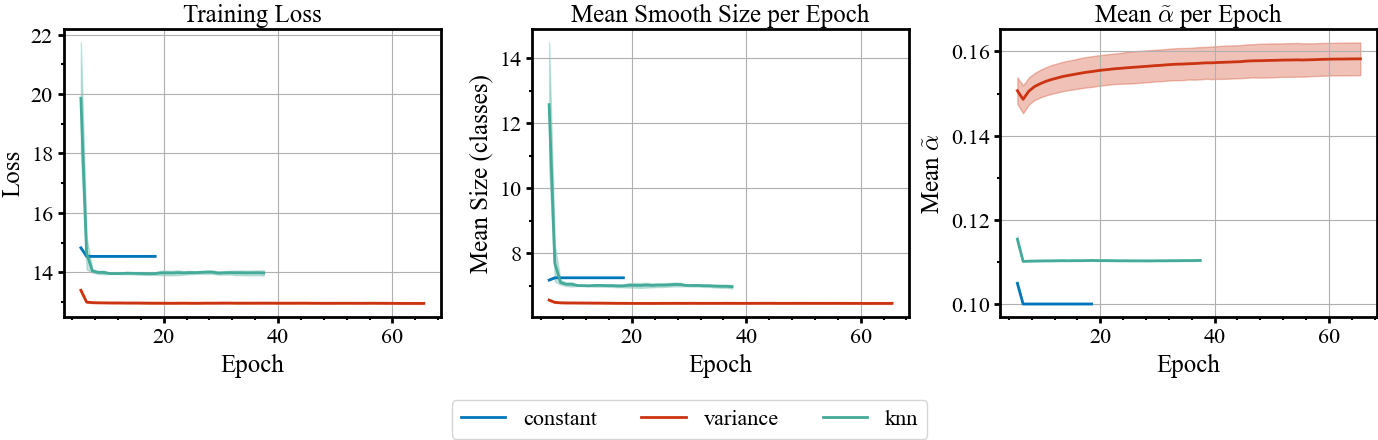

In [22]:
# learned path: make_features_reg = [Sigma/n, u] has no scale term -> MAE only
assert np.allclose(s_calib, 1) and np.allclose(s_test, 1), "learned path is MAE-only"

train_loaders = {m: anet.make_loader_reg(Sigma_loo, n_loo, U_loo[m]) for m in METHODS}
num_runs, num_epochs, lr = 4, 200, 1e-2
all_results = anet.run_uncertainty_ablation(
    train_loaders, lam, num_epochs=num_epochs, lr=lr, num_runs=num_runs,
    patience=20, regression=True, device=device)
anet.plot_performance(all_results, path=f"plots/alpha_net_reg_uq_ablation_{dataname}_data.pdf")

In [23]:
def net_alphas(net, Sigma, n, u):
    net.eval()
    with torch.no_grad():
        x = torch.tensor(anet.make_features_reg(Sigma, n, u), dtype=torch.float32).to(device)
        return net(x).cpu().numpy()

learned = {n: {
    "alpha_loo":  np.stack([net_alphas(net, Sigma_loo, n_loo,  U_loo[n])  for net in all_results[n]["nets"]]),
    "alpha_test": np.stack([net_alphas(net, Sigma_te,  n_calib, U_test[n]) for net in all_results[n]["nets"]]),
} for n in METHODS}


rows = []
for n in METHODS:
    u, a_cf, a_nn = U_loo[n], closed[n]["alpha_loo"], learned[n]["alpha_loo"]
    L_cf = reg_loss(Sigma_loo, n_loo, a_cf, lam, u, s_calib).mean()
    L_nn = np.array([reg_loss(Sigma_loo, n_loo, a, lam, u, s_calib).mean() for a in a_nn])
    rows.append({"method": n, "loss closed": L_cf, "loss learned": L_nn.mean(), "sd": L_nn.std(),
                 "rel. gap %": 100 * (L_nn.mean() - L_cf) / L_cf,
                 "max |a_nn - a*|": np.abs(a_nn - a_cf).max(),
                 "corr": np.mean([np.corrcoef(a, a_cf)[0, 1] for a in a_nn]) if np.ptp(U_loo[n]) > 1e-8 else np.nan})
print(pd.DataFrame(rows).set_index("method").round(4).to_string())

          loss closed  loss learned      sd  rel. gap %  max |a_nn - a*|    corr
method                                                                          
constant      14.5380       14.5380  0.0000      0.0000           0.0003     NaN
variance      12.9435       12.9555  0.0095      0.0922           0.6078  0.9485
knn           13.8478       13.9135  0.0465      0.4747           0.0169  0.9965


In [24]:
def evaluate_reg(alphas, Sigma=Sigma_te, n=n_calib, S=S_test, scale=s_test):
    r = radius(Sigma, n, alphas)               
    return (S <= r).astype(int), 2 * r * scale, np.asarray(alphas, float)

def set_metrics(cov, sizes, alphas):
    c, a, fin = float(np.mean(cov)), float(np.mean(alphas)), np.isfinite(sizes)
    return {"mean alpha": a, "nominal cov": 1 - a, "coverage": c, "gap": c - (1 - a),
            "mean size": float(np.mean(sizes[fin])) if fin.any() else np.inf,
            "% infinite": 100.0 * float(np.mean(~fin))}

def aggregate(per_run):
    return {k: (np.mean([r[k] for r in per_run]), np.std([r[k] for r in per_run])) for k in per_run[0]}

POLICIES = {"closed":  {n: closed[n]["alpha_test"][None] for n in METHODS},
            "learned": {n: learned[n]["alpha_test"]      for n in METHODS}}
raw   = {p: {n: [evaluate_reg(a) for a in POLICIES[p][n]] for n in METHODS} for p in POLICIES}
table = {(n, p): aggregate([set_metrics(*r) for r in raw[p][n]]) for p in POLICIES for n in METHODS}

metrics = list(next(iter(table.values())))
df_num = pd.DataFrame({m: {k: table[k][m][0] for k in table} for m in metrics})
df_std = pd.DataFrame({m: {k: table[k][m][1] for k in table} for m in metrics})
print((df_num.round(3).astype(str) + " ± " + df_std.round(3).astype(str)).to_string())
print("\n" + df_num.round(3).to_latex())

                     mean alpha    nominal cov     coverage            gap       mean size % infinite
constant closed       0.1 ± 0.0      0.9 ± 0.0    1.0 ± 0.0      0.1 ± 0.0     7.251 ± 0.0  0.0 ± 0.0
variance closed     0.163 ± 0.0    0.837 ± 0.0  0.999 ± 0.0    0.162 ± 0.0     6.487 ± 0.0  0.0 ± 0.0
knn      closed     0.111 ± 0.0    0.889 ± 0.0    1.0 ± 0.0    0.111 ± 0.0     6.892 ± 0.0  0.0 ± 0.0
constant learned      0.1 ± 0.0      0.9 ± 0.0    1.0 ± 0.0      0.1 ± 0.0   7.251 ± 0.001  0.0 ± 0.0
variance learned  0.157 ± 0.004  0.843 ± 0.004  0.999 ± 0.0  0.157 ± 0.004   6.527 ± 0.054  0.0 ± 0.0
knn      learned  0.114 ± 0.003  0.886 ± 0.003    1.0 ± 0.0  0.114 ± 0.003  12.561 ± 2.609  0.0 ± 0.0

\begin{tabular}{llrrrrrr}
\toprule
 &  & mean alpha & nominal cov & coverage & gap & mean size & % infinite \\
\midrule
constant & closed & 0.100000 & 0.900000 & 1.000000 & 0.100000 & 7.251000 & 0.000000 \\
\cline{1-8}
variance & closed & 0.163000 & 0.837000 & 0.999000 & 0.162000 & 6.

In [25]:
def outcomes(policy):
    A, SZ, MISS = {}, {}, {}
    for n in METHODS:
        runs = raw[policy][n]
        A[n]    = np.mean([a for _, _, a in runs], axis=0)
        SZ[n]   = np.mean([s for _, s, _ in runs], axis=0)
        MISS[n] = np.mean([1.0 - c for c, _, _ in runs], axis=0)
    return {"alpha": A, "size": SZ, "miscoverage": MISS}

OUTCOMES_BY_POLICY = {p: outcomes(p) for p in POLICIES}
OUTCOMES = OUTCOMES_BY_POLICY["learned"]    # set to "closed" and rerun the stats cells
CONTROL  = "constant"

C:\Users\User\AppData\Local\Temp\ipykernel_41668\3945956085.py:25: UserWarning: The figure layout has changed to tight
  axs[0].legend(frameon=True); plt.tight_layout()


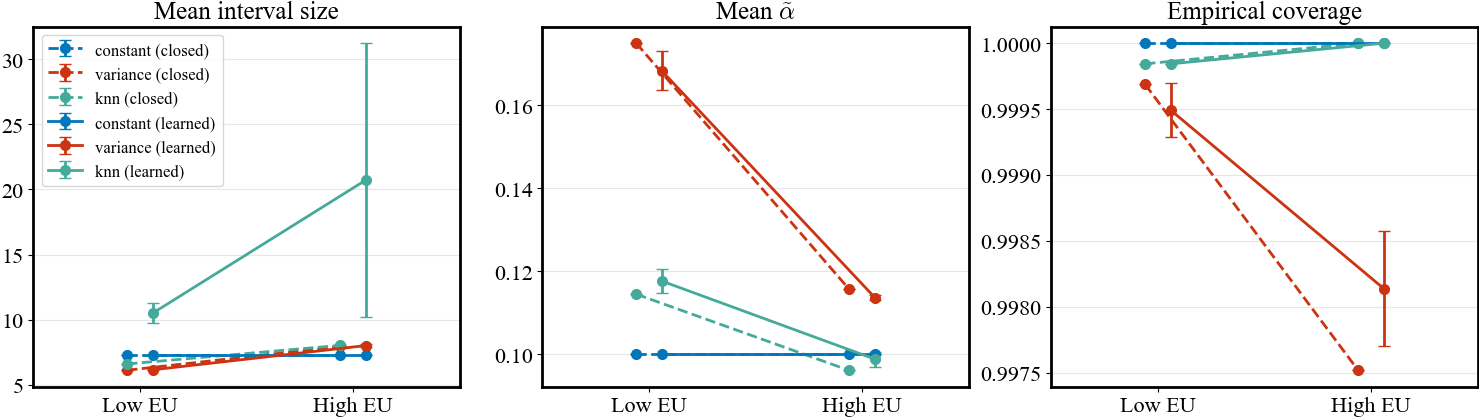

C:\Users\User\AppData\Local\Temp\ipykernel_41668\3945956085.py:35: UserWarning: The figure layout has changed to tight
  axs[0].set_ylabel(r"$\tilde\alpha_\theta$ (learned)"); plt.tight_layout()


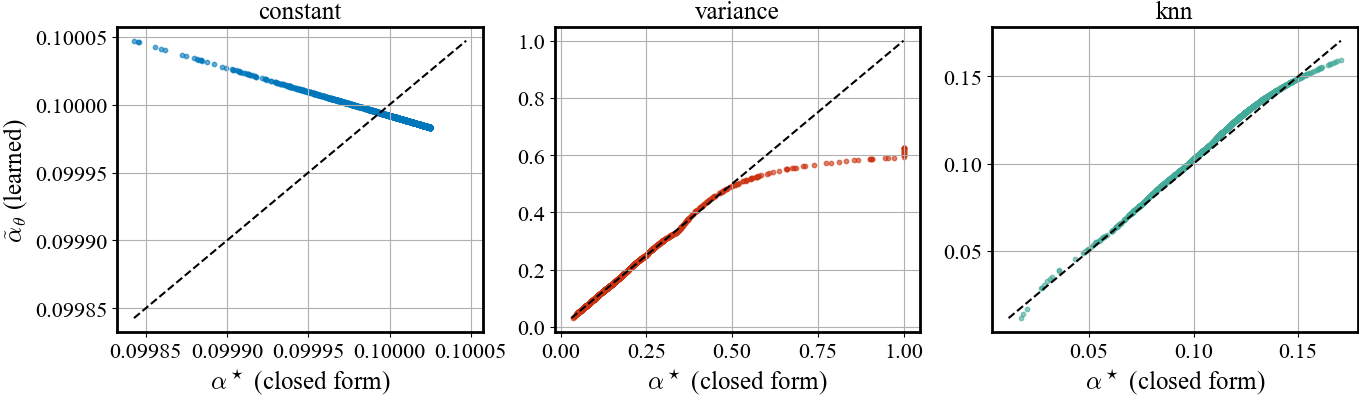

In [26]:
import matplotlib.pyplot as plt
from tueplots import bundles
plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({"axes.labelsize": 18, "axes.titlesize": 18, "xtick.labelsize": 16,
                     "ytick.labelsize": 16, "legend.fontsize": 12, "lines.linewidth": 2, "axes.linewidth": 2})

GROUPS, LABEL = ["rest", "eu"], {"rest": "Low EU", "eu": "High EU"}
PANELS = [("size", "Mean interval size"), ("alpha", r"Mean $\tilde\alpha$"), ("coverage", "Empirical coverage")]
colors = dict(zip(METHODS, anet._PALETTE))
ls, off = {"closed": "--", "learned": "-"}, {"closed": -0.06, "learned": 0.06}

def group_stat(run, g, key):
    cov, sz, a = run; msk = group_test == g
    return {"size": sz[msk].mean(), "alpha": a[msk].mean(), "coverage": cov[msk].mean()}[key]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (key, title) in zip(axs, PANELS):
    for p in POLICIES:
        for n in METHODS:
            v = np.array([[group_stat(r, g, key) for g in GROUPS] for r in raw[p][n]])
            ax.errorbar(np.arange(2) + off[p], v.mean(0), yerr=v.std(0), color=colors[n],
                        ls=ls[p], marker="o", ms=7, capsize=4, label=f"{n} ({p})")
    ax.set_xticks([0, 1]); ax.set_xticklabels([LABEL[g] for g in GROUPS])
    ax.set_xlim(-0.5, 1.5); ax.set_title(title); ax.grid(True, axis="y", alpha=0.3)
axs[0].legend(frameon=True); plt.tight_layout()
plt.savefig(f"plots/reg_groups_by_method_{dataname}_data.pdf", bbox_inches="tight"); plt.show()

fig, axs = plt.subplots(1, len(METHODS), figsize=(4.6 * len(METHODS), 4.2))
for ax, n in zip(axs, METHODS):
    a_cf, a_nn = closed[n]["alpha_loo"], learned[n]["alpha_loo"].mean(0)
    ax.scatter(a_cf, a_nn, s=10, alpha=0.6, color=colors[n])
    lo, hi = min(a_cf.min(), a_nn.min()), max(a_cf.max(), a_nn.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
    ax.set_title(n); ax.set_xlabel(r"$\alpha^\star$ (closed form)"); ax.grid(True)
axs[0].set_ylabel(r"$\tilde\alpha_\theta$ (learned)"); plt.tight_layout()
plt.savefig(f"plots/reg_closed_vs_learned_{dataname}_data.pdf", bbox_inches="tight"); plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_41668\1439490858.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


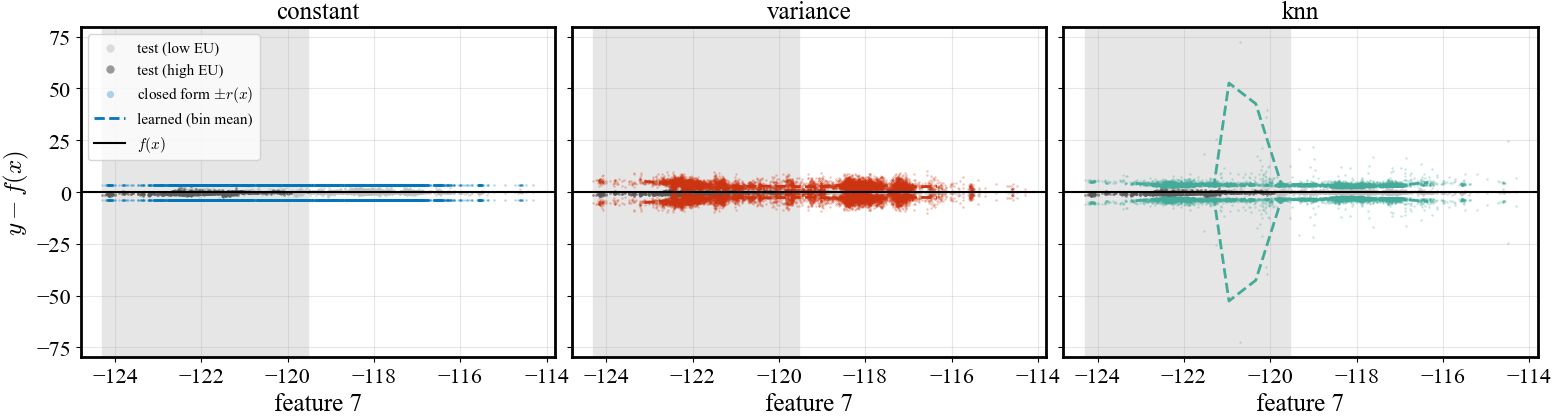

In [ ]:
# Cell 14 — data + prediction intervals (closed form: shaded, learned: dashed)
PLOT_FEATURE = 0     # x-axis column when d > 1 (set to the feature that defines the EU region)
if dataname=="CALIFORNIA":
    PLOT_FEATURE=6
N_BINS       = 30    # bins for the learned-radius curve when d > 1

def intervals(Xq, name):
    """f(x), closed-form radius, learned radius (mean over runs) at query points Xq."""
    u    = uncertainty_methods[name].transform_normalized(UncertaintyData(X=Xq))
    a_cf = alpha_star(Sigma_te, n_calib, lam, u)
    a_nn = np.stack([net_alphas(net, Sigma_te, n_calib, u) for net in all_results[name]["nets"]])
    return model.predict(Xq), radius(Sigma_te, n_calib, a_cf), radius(Sigma_te, n_calib, a_nn).mean(0)

one_d  = X_test.shape[1] == 1
x_test = X_test[:, PLOT_FEATURE]
f_te, _, _ = intervals(X_test, METHODS[0])
y_plot = y_test if one_d else y_test - f_te        # d > 1: centre every point on its own f(x)

fig, axs = plt.subplots(1, len(METHODS), figsize=(5.2 * len(METHODS), 4.4), sharey=True)
for ax, name in zip(axs, METHODS):
    c = colors[name]
    ax.axvspan(x_test[EU].min(), x_test[EU].max(), color="0.9", zorder=0)   # exact when EU is a range of this feature
    ax.scatter(x_test[~EU], y_plot[~EU], s=4, color="0.75", alpha=0.5, lw=0, label="test (low EU)",  zorder=1)
    ax.scatter(x_test[EU],  y_plot[EU],  s=4, color="0.35", alpha=0.6, lw=0, label="test (high EU)", zorder=1)

    if one_d:
        g = np.linspace(x_test.min(), x_test.max(), 400)
        f, r_cf, r_nn = intervals(g[:, None].astype(np.float32), name)
        ax.fill_between(g, f - r_cf, f + r_cf, color=c, alpha=0.25, lw=0, label="closed form", zorder=2)
        ax.plot(g, f + r_nn, color=c, ls="--", lw=2, label="learned", zorder=3)
        ax.plot(g, f - r_nn, color=c, ls="--", lw=2, zorder=3)
        ax.plot(g, f, color="k", lw=1.5, label=r"$f(x)$", zorder=4)
    else:
        _, r_cf, r_nn = intervals(X_test, name)
        ax.scatter(np.r_[x_test, x_test], np.r_[r_cf, -r_cf], s=3, color=c, alpha=0.3, lw=0,
                   label=r"closed form $\pm r(x)$", zorder=2)
        b  = np.clip(np.digitize(x_test, np.quantile(x_test, np.linspace(0, 1, N_BINS + 1))[1:-1]), 0, N_BINS - 1)
        xm = np.array([x_test[b == k].mean() for k in range(N_BINS)])
        rm = np.array([r_nn[b == k].mean()   for k in range(N_BINS)])
        ax.plot(xm,  rm, color=c, ls="--", lw=2, label="learned (bin mean)", zorder=3)
        ax.plot(xm, -rm, color=c, ls="--", lw=2, zorder=3)
        ax.axhline(0, color="k", lw=1.5, label=r"$f(x)$", zorder=4)

    ax.set_title(name)
    ax.set_xlabel(r"$x$" if one_d else f"feature {PLOT_FEATURE}")
    ax.grid(True, alpha=0.3)

axs[0].set_ylabel(r"$y$" if one_d else r"$y - f(x)$")
axs[0].legend(frameon=True, loc="upper left", fontsize=11, markerscale=3)
plt.tight_layout()
plt.savefig(f"plots/reg_intervals_{dataname}_data.pdf", bbox_inches="tight")
plt.show()

In [45]:

import json, urllib.request
from matplotlib.path import Path
from matplotlib.patches import PathPatch

if dataname=="CALIFORNIA":
    LON, LAT = 7, 6          # California column indices (Longitude, Latitude)
    POLICY   = "closed"      # or "learned"
    GRID     = 60
    GEO_URL  = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
    GEO_FILE = "us-states.json"

    if not os.path.exists(GEO_FILE):
        urllib.request.urlretrieve(GEO_URL, GEO_FILE)
    ca = next(f for f in json.load(open(GEO_FILE))["features"] if f["properties"]["name"] == "California")
    rings = ca["geometry"]["coordinates"]
    rings = [p[0] for p in rings] if ca["geometry"]["type"] == "MultiPolygon" else [rings[0]]
    ca_path = Path.make_compound_path(*[Path(np.asarray(r)) for r in rings])

    lon, lat = X_test[:, LON], X_test[:, LAT]
    width    = {n: np.mean([s for _, s, _ in raw[POLICY][n]], axis=0) for n in METHODS}
    lat_cut  = lat[EU].min()
    ratio    = {n: np.log2(width[n] / width["constant"]) for n in AWARE}
    vmax     = max(np.abs(np.quantile(r, [0.02, 0.98])).max() for r in ratio.values())

    def draw_state(ax, C, **kw):
        ax.add_patch(PathPatch(ca_path, facecolor="0.93", edgecolor="none", zorder=0))    # no-data base
        hb = ax.hexbin(lon, lat, C=C, gridsize=GRID, reduce_C_function=np.mean, mincnt=1, lw=0, zorder=1, **kw)
        hb.set_clip_path(PathPatch(ca_path, transform=ax.transData))
        ax.add_patch(PathPatch(ca_path, facecolor="none", edgecolor="k", lw=1.2, zorder=3))
        # EU region: dashed latitude cut, clipped to the state, with a label
        ln, = ax.plot([-125, -113], [lat_cut, lat_cut], color="k", ls="--", lw=1.3, zorder=4)
        ln.set_clip_path(PathPatch(ca_path, transform=ax.transData))
        ax.text(-119.6, lat_cut + 0.25, "high EU (thinned)", fontsize=11, va="bottom", zorder=5)
        ax.text(-119.6, lat_cut - 0.25, "low EU",            fontsize=11, va="top",    zorder=5)
        ax.set_xlim(-124.6, -113.9); ax.set_ylim(32.3, 42.2)
        ax.set_aspect(1 / np.cos(np.deg2rad(37.5)))              # equirectangular, true shape at CA's latitude
        ax.set_xlabel(r"longitude ($^\circ$)")
        for s in ax.spines.values(): s.set_visible(False)
        return hb

    fig, axs = plt.subplots(1, 1 + len(AWARE), figsize=(4.6 * (1 + len(AWARE)), 5.2), sharex=True, sharey=True)

    hb0 = draw_state(axs[0], np.abs(y_test - f_test), cmap="viridis")
    axs[0].set_title(r"mean $|y - f(x)|$")
    fig.colorbar(hb0, ax=axs[0], shrink=0.7)

    for ax, n in zip(axs[1:], AWARE):
        hb = draw_state(ax, ratio[n], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(rf"{n}: $\log_2$(width / constant)")
    fig.colorbar(hb, ax=axs[1:], shrink=0.7, label="red = wider, blue = narrower")

    axs[0].set_ylabel(r"latitude ($^\circ$)")
    plt.savefig(f"plots/reg_map_{POLICY}_{dataname}_data.pdf", bbox_inches="tight")
    plt.show()

KeyError: 'closed'

In [35]:
import json, urllib.request
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.colors import LogNorm

if dataname == "CALIFORNIA":
    if not os.path.exists(GEO_FILE):
        urllib.request.urlretrieve(GEO_URL, GEO_FILE)
    ca = next(f for f in json.load(open(GEO_FILE))["features"] if f["properties"]["name"] == "California")
    rings = ca["geometry"]["coordinates"]
    rings = [p[0] for p in rings] if ca["geometry"]["type"] == "MultiPolygon" else [rings[0]]
    ca_path = Path.make_compound_path(*[Path(np.asarray(r)) for r in rings])

    lon, lat = X_test[:, LON], X_test[:, LAT]
    width    = {n: np.mean([s for _, s, _ in raw[POLICY][n]], axis=0) for n in METHODS}
    lat_cut  = lat[EU].min()
    pooled   = np.concatenate([width[n] for n in METHODS])
    norm     = LogNorm(*np.quantile(pooled, [0.02, 0.98]))       # one shared scale for all panels

    def draw_state(ax, C, **kw):
        ax.add_patch(PathPatch(ca_path, facecolor="0.93", edgecolor="none", zorder=0))    # no-data base
        hb = ax.hexbin(lon, lat, C=C, gridsize=GRID, reduce_C_function=np.mean, mincnt=1, lw=0, zorder=1, **kw)
        hb.set_clip_path(PathPatch(ca_path, transform=ax.transData))
        ax.add_patch(PathPatch(ca_path, facecolor="none", edgecolor="k", lw=1.2, zorder=3))
        # EU region: dashed latitude cut, clipped to the state, with a label
        ln, = ax.plot([-125, -113], [lat_cut, lat_cut], color="k", ls="--", lw=1.3, zorder=4)
        ln.set_clip_path(PathPatch(ca_path, transform=ax.transData))
        ax.text(-119.6, lat_cut + 0.25, "high EU (thinned)", fontsize=11, va="bottom", zorder=5)
        ax.text(-119.6, lat_cut - 0.25, "low EU",            fontsize=11, va="top",    zorder=5)
        ax.set_xlim(-124.6, -113.9); ax.set_ylim(32.3, 42.2)
        ax.set_aspect(1 / np.cos(np.deg2rad(37.5)))              # equirectangular, true shape at CA's latitude
        ax.set_xlabel(r"longitude ($^\circ$)")
        for s in ax.spines.values(): s.set_visible(False)
        return hb

    fig, axs = plt.subplots(1, len(METHODS), figsize=(4.6 * len(METHODS), 5.2), sharex=True, sharey=True)
    for ax, n in zip(axs, METHODS):
        hb = draw_state(ax, width[n], cmap="viridis", norm=norm)
        ax.set_title(n)
    cb = fig.colorbar(hb, ax=axs, shrink=0.7, label="mean interval width")
    ticks = np.geomspace(norm.vmin, norm.vmax, 5)
    cb.minorticks_off(); cb.set_ticks(ticks); cb.set_ticklabels([f"{t:.2g}" for t in ticks])

    axs[0].set_ylabel(r"latitude ($^\circ$)")
    plt.savefig(f"plots/reg_map_{POLICY}_{dataname}_data.pdf", bbox_inches="tight")
    plt.show()

NameError: name 'GEO_FILE' is not defined

In [ ]:
# Cell 16 — AISL (average interval score loss, Gneiting & Raftery 2007)
#   IS_alpha(l, u; y) = (u - l) + (2/alpha)(l - y) 1{y < l} + (2/alpha)(y - u) 1{y > u}
#   symmetric interval f +- r  ->  IS = 2r + (2/alpha) max(|y - f| - r, 0), with each point's own alpha

def interval_score(sizes, alphas, y=y_test, f=f_test):
    r = sizes / 2
    return sizes + (2.0 / alphas) * np.maximum(np.abs(y - f) - r, 0.0)

rows = []
for p in POLICIES:
    for n in METHODS:
        per_run = [interval_score(sz, a) for _, sz, a in raw[p][n]]
        agg = lambda m: (np.mean([s[m].mean() for s in per_run]), np.std([s[m].mean() for s in per_run]))
        row = {"method": n, "policy": p}
        for g, m in [("all", np.ones(len(EU), bool)), ("high EU", EU), ("low EU", ~EU)]:
            mu, sd = agg(m)
            row[f"AISL {g}"] = f"{mu:.3f} ± {sd:.3f}"
        rows.append(row)
print(pd.DataFrame(rows).set_index(["method", "policy"]).to_string())